In [1]:
import h5py as h5
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import csv
import h5py
from torchvision.models import resnet18
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from PIL import Image
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import warnings 
warnings.filterwarnings("ignore")

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
data = h5py.File('/kaggle/input/rotated-mnist-dataset/mnist_rotated_pair.h5', 'r')

In [4]:
class RotatedMNIST:
    def __init__(self,data,transform):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data['rotated_images'])
    def __getitem__(self,idx):
        rotated_img = self.data['rotated_images'][idx]
        original_img = self.data['original_images'][idx]
        angle = self.data['angle_rotated'][idx]
        label = self.data['labels'][idx]
        # rotated_img = np.repeat(rotated_img[:,:,np.newaxis],3,axis = -1)
        # original_img = np.repeat(original_img[:,:,np.newaxis],3,axis = -1)
        if self.transform != None:
            rotated_img = self.transform(image = rotated_img)['image']
        return rotated_img, original_img, label, angle

In [5]:
transform = A.Compose([
    ToTensorV2(),
])
dataset = RotatedMNIST(data,transform)
dataloader = DataLoader(dataset, batch_size = 64, shuffle = True, num_workers = os.cpu_count())

In [6]:
all_images = data["rotated_images"][:]  
all_labels = data["labels"][:]         
all_angles = data["angle_rotated"][:]   

N = all_images.shape[0]
strat_keys = np.array([f"{label}_{angle}" for label, angle in zip(all_labels, all_angles)])
indices = np.arange(N)

train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=42, stratify=strat_keys)

class OracleDataset():
    def __init__(self, hdf5_file, indices):
        self.indices = indices
        self.file = hdf5_file
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        index = self.indices[idx]
        image = self.file["rotated_images"][index]
        label = self.file["labels"][index]
        angle = self.file["angle_rotated"][index]
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.long)
        angle = torch.tensor(angle, dtype=torch.float32)
        return image, label, angle

train_dataset = OracleDataset(data, train_idx)
val_dataset = OracleDataset(data, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        resnet = models.resnet18(pretrained=True)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity() 
        self.encoder = nn.Sequential(
            resnet.conv1,   
            resnet.bn1,
            resnet.relu,
            resnet.layer1,  
            resnet.layer2,  
            resnet.layer3,  
            resnet.layer4,  
            resnet.avgpool, 
            nn.Flatten()    
        )
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)
        
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),  
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        h_decode = self.fc_decode(z)
        x_recon = self.decoder(h_decode)
        return x_recon, mu, logvar

In [8]:
model = VAE(latent_dim = 2).to(device)
model.load_state_dict(torch.load('/kaggle/input/vae/pytorch/default/1/VAE.pth', weights_only = True)['model_state_dict'])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


<All keys matched successfully>

In [9]:
class OracleMLP(nn.Module):
    def __init__(self, latent_dim):
        super(OracleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  
        )
        
    def forward(self, z):
        return self.fc(z)

latent_dim = 2  
oracle = OracleMLP(latent_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer_oracle = optim.Adam(oracle.parameters(), lr=1e-3)

model.eval()
for param in model.parameters():
    param.requires_grad = False

num_epochs = 5
for epoch in range(num_epochs):
    oracle.train()
    running_loss = 0.0
    total_samples = 0
    correct_samples = 0
    
    for images, labels, angles in tqdm(train_loader):
        images = images.to(device) / 255.0
        labels = (labels - 1).to(device)

        with torch.no_grad():
            _, z, _ = model(images)  
        
        logits = oracle(z)  
        loss = criterion(logits, labels.unsqueeze(1).float())
        
        optimizer_oracle.zero_grad()
        loss.backward()
        optimizer_oracle.step()
        
        running_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long().squeeze(1)
        correct_samples += (preds == labels).sum().item()
    
    train_loss = running_loss / total_samples
    train_acc = 100.0 * correct_samples / total_samples
 
    oracle.eval()
    all_gt = []
    all_prob = []
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels, angles in tqdm(val_loader):
            images = images.to(device) / 255.0
            labels = (labels-1).to(device)
            _, z, _ = model(images)
            logits = oracle(z)
            probs = torch.sigmoid(logits).squeeze(1)
            preds = (probs > 0.5).long()
            
            all_gt.extend(labels.cpu().numpy())
            all_prob.extend(probs.cpu().numpy())
            
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()
    
    val_acc = 100.0 * val_correct / val_total
    auc_score = roc_auc_score(all_gt, all_prob)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%, AUC: {auc_score:.4f}")

print("Oracle training complete.")

100%|██████████| 558/558 [00:11<00:00, 48.34it/s]


Epoch 1/5 | Train Loss: 0.1054, Train Acc: 98.22% | Val Acc: 98.83%, AUC: 0.9927


100%|██████████| 558/558 [00:11<00:00, 48.07it/s]


Epoch 2/5 | Train Loss: 0.0667, Train Acc: 98.81% | Val Acc: 98.76%, AUC: 0.9926


100%|██████████| 558/558 [00:11<00:00, 48.10it/s]


Epoch 3/5 | Train Loss: 0.0626, Train Acc: 98.81% | Val Acc: 98.79%, AUC: 0.9926


100%|██████████| 558/558 [00:11<00:00, 47.80it/s]


Epoch 4/5 | Train Loss: 0.0598, Train Acc: 98.83% | Val Acc: 98.83%, AUC: 0.9926


100%|██████████| 558/558 [00:11<00:00, 47.62it/s]

Epoch 5/5 | Train Loss: 0.0583, Train Acc: 98.82% | Val Acc: 98.81%, AUC: 0.9927
Oracle training complete.


In [30]:
from itertools import combinations

def normalized_dot(a, b):
    return torch.sum(a * b, dim=1) / (torch.norm(a, dim=1) * torch.norm(b, dim=1) + 1e-16)

class SymmetryNet(nn.Module):
    def __init__(self, latent_dim):
        super(SymmetryNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
    
    def forward(self, z):
        return self.net(z)

latent_dim = 2
epsilon = 1.5
num_epochs_sym = 5
lr_sym = 0.05
N_g = 3

hnorm = 1.0
hortho = 1.5
hclos = 0.0

sym_nets = nn.ModuleList([SymmetryNet(latent_dim).to(device) for _ in range(N_g)])
optimizer_sym = optim.Adam(sym_nets.parameters(), lr=lr_sym)

model.eval()
oracle.eval()
for param in model.parameters():
    param.requires_grad = False
for param in oracle.parameters():
    param.requires_grad = False

for epoch in range(num_epochs_sym):
    sym_nets.train()
    running_loss = 0.0
    for batch in tqdm(dataloader, desc=f"Symmetry Epoch {epoch+1}/{num_epochs_sym}"):
        rotated_img, original_img, labels, angles = batch
        rotated_img = rotated_img.to(device).float() / 255.0
        
        with torch.no_grad():
            _, z, _ = model(rotated_img)
        
        invariance_loss_total = 0.0
        normalization_loss_total = 0.0
        delta_list = []
        
        for g in sym_nets:
            delta_z = g(z)
            delta_list.append(delta_z)
            z_prime = z + epsilon * delta_z
            
            with torch.no_grad():
                logit_orig = oracle(z)
                logit_sym = oracle(z_prime)
            inv_loss = nn.functional.mse_loss(logit_sym, logit_orig) / (epsilon ** 2)
            invariance_loss_total += inv_loss
            
            norm = torch.norm(delta_z, dim=1)
            norm_loss1 = nn.functional.mse_loss(norm, torch.ones_like(norm))
            mean_norm = norm.mean()
            norm_loss2 = nn.functional.mse_loss(norm, mean_norm * torch.ones_like(norm))
            normalization_loss_total += (norm_loss1 + norm_loss2)
        
        invariance_loss_total = invariance_loss_total / N_g
        normalization_loss_total = normalization_loss_total / N_g
        
        ortho_loss = 0.0
        for i, j in combinations(range(N_g), 2):
            dot_prod = normalized_dot(delta_list[i], delta_list[j])
            ortho_loss += torch.mean(dot_prod ** 2)
        num_pairs = N_g * (N_g - 1) / 2
        if num_pairs > 0:
            ortho_loss = ortho_loss / num_pairs
        
        closure_loss = 0.0
        
        total_loss = (invariance_loss_total +
                      hnorm * normalization_loss_total +
                      hortho * ortho_loss +
                      hclos * closure_loss)
        
        optimizer_sym.zero_grad()
        total_loss.backward()
        optimizer_sym.step()
        
        running_loss += total_loss.item()
    
    avg_loss = running_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs_sym} - Total Loss: {avg_loss:.4f}")

print("Symmetry discovery training complete.")

Symmetry Epoch 1/5: 100%|██████████| 2788/2788 [01:07<00:00, 41.34it/s]


Epoch 1/5 - Total Loss: 133.2051


Symmetry Epoch 2/5: 100%|██████████| 2788/2788 [01:06<00:00, 41.94it/s]


Epoch 2/5 - Total Loss: 132.8546


Symmetry Epoch 3/5: 100%|██████████| 2788/2788 [01:05<00:00, 42.46it/s]


Epoch 3/5 - Total Loss: 132.4611


Symmetry Epoch 4/5: 100%|██████████| 2788/2788 [01:05<00:00, 42.82it/s]


Epoch 4/5 - Total Loss: 133.1901


Symmetry Epoch 5/5: 100%|██████████| 2788/2788 [01:05<00:00, 42.52it/s]

Epoch 5/5 - Total Loss: 134.1698
Symmetry discovery training complete.


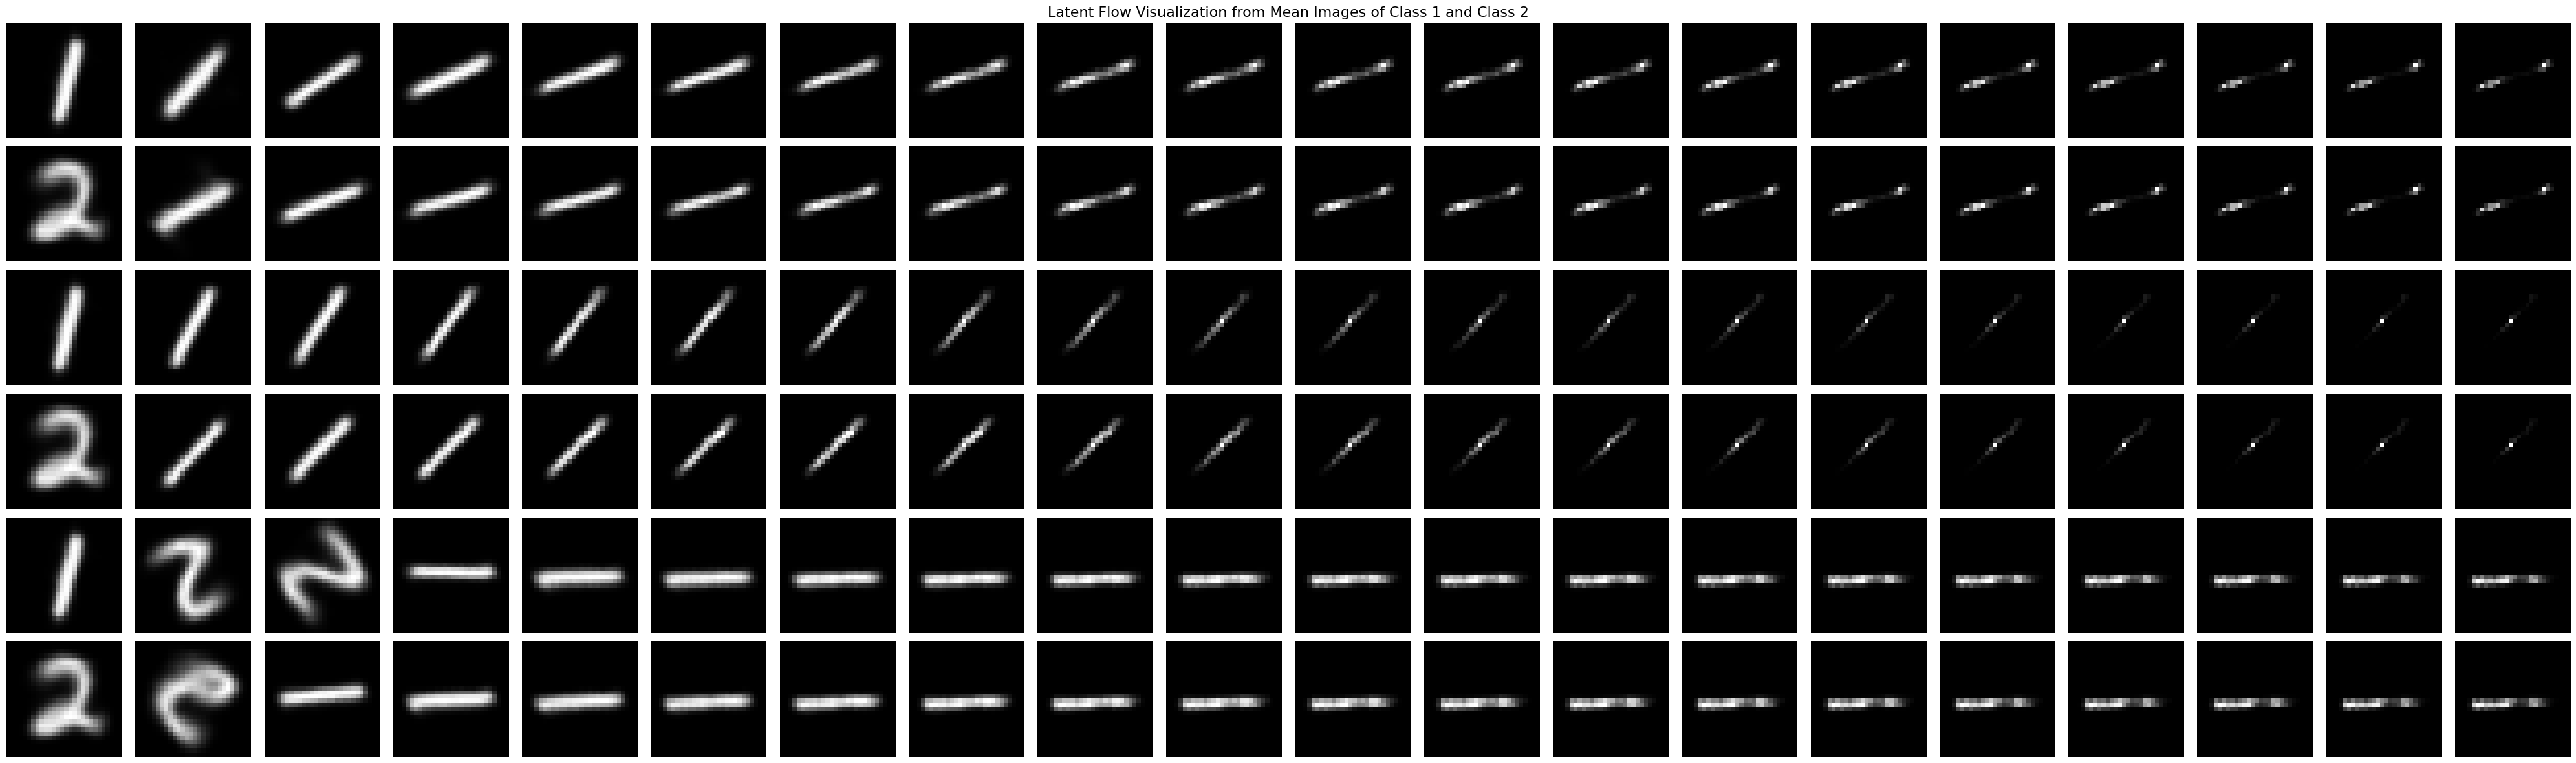

In [12]:
flows_class1 = []
flows_class2 = []

for idx, sym_net in enumerate(sym_nets):
    with torch.no_grad():
        z_current = z_mean1.clone()
        flow_images = []
        for step in range(num_steps_flow):
            h_z = model.fc_decode(z_current)
            img_decoded = model.decoder(h_z)
            flow_images.append(img_decoded.cpu().squeeze().numpy())
            delta_z = sym_net(z_current)
            z_current = z_current - epsilon * delta_z
        flows_class1.append(flow_images)

for idx, sym_net in enumerate(sym_nets):
    with torch.no_grad():
        z_current = z_mean2.clone()
        flow_images = []
        for step in range(num_steps_flow):
            h_z = model.fc_decode(z_current)
            img_decoded = model.decoder(h_z)
            flow_images.append(img_decoded.cpu().squeeze().numpy())
            delta_z = sym_net(z_current)
            z_current = z_current - epsilon * delta_z
        flows_class2.append(flow_images)

num_gens = len(sym_nets)
fig, axes = plt.subplots(2 * num_gens, num_steps_flow, figsize=(num_steps_flow * 2, 2 * num_gens * 2))
for i in range(num_gens):
    for j in range(num_steps_flow):
        ax1 = axes[2*i, j] if num_gens > 1 else axes[j]
        ax1.imshow(flows_class1[i][j], cmap='gray')
        ax1.axis('off')
        if j == 0:
            ax1.set_ylabel(f"Gen {i+1} (Class 1)", fontsize=10)
        ax2 = axes[2*i+1, j] if num_gens > 1 else axes[j]
        ax2.imshow(flows_class2[i][j], cmap='gray')
        ax2.axis('off')
        if j == 0:
            ax2.set_ylabel(f"Gen {i+1} (Class 2)", fontsize=10)
plt.suptitle("Latent Flow Visualization from Mean Images of Class 1 and Class 2", fontsize=16)
plt.tight_layout()
plt.show()

Computing mean images: 100%|██████████| 2788/2788 [00:51<00:00, 54.02it/s]


Computed mean images for class 1 and class 2.


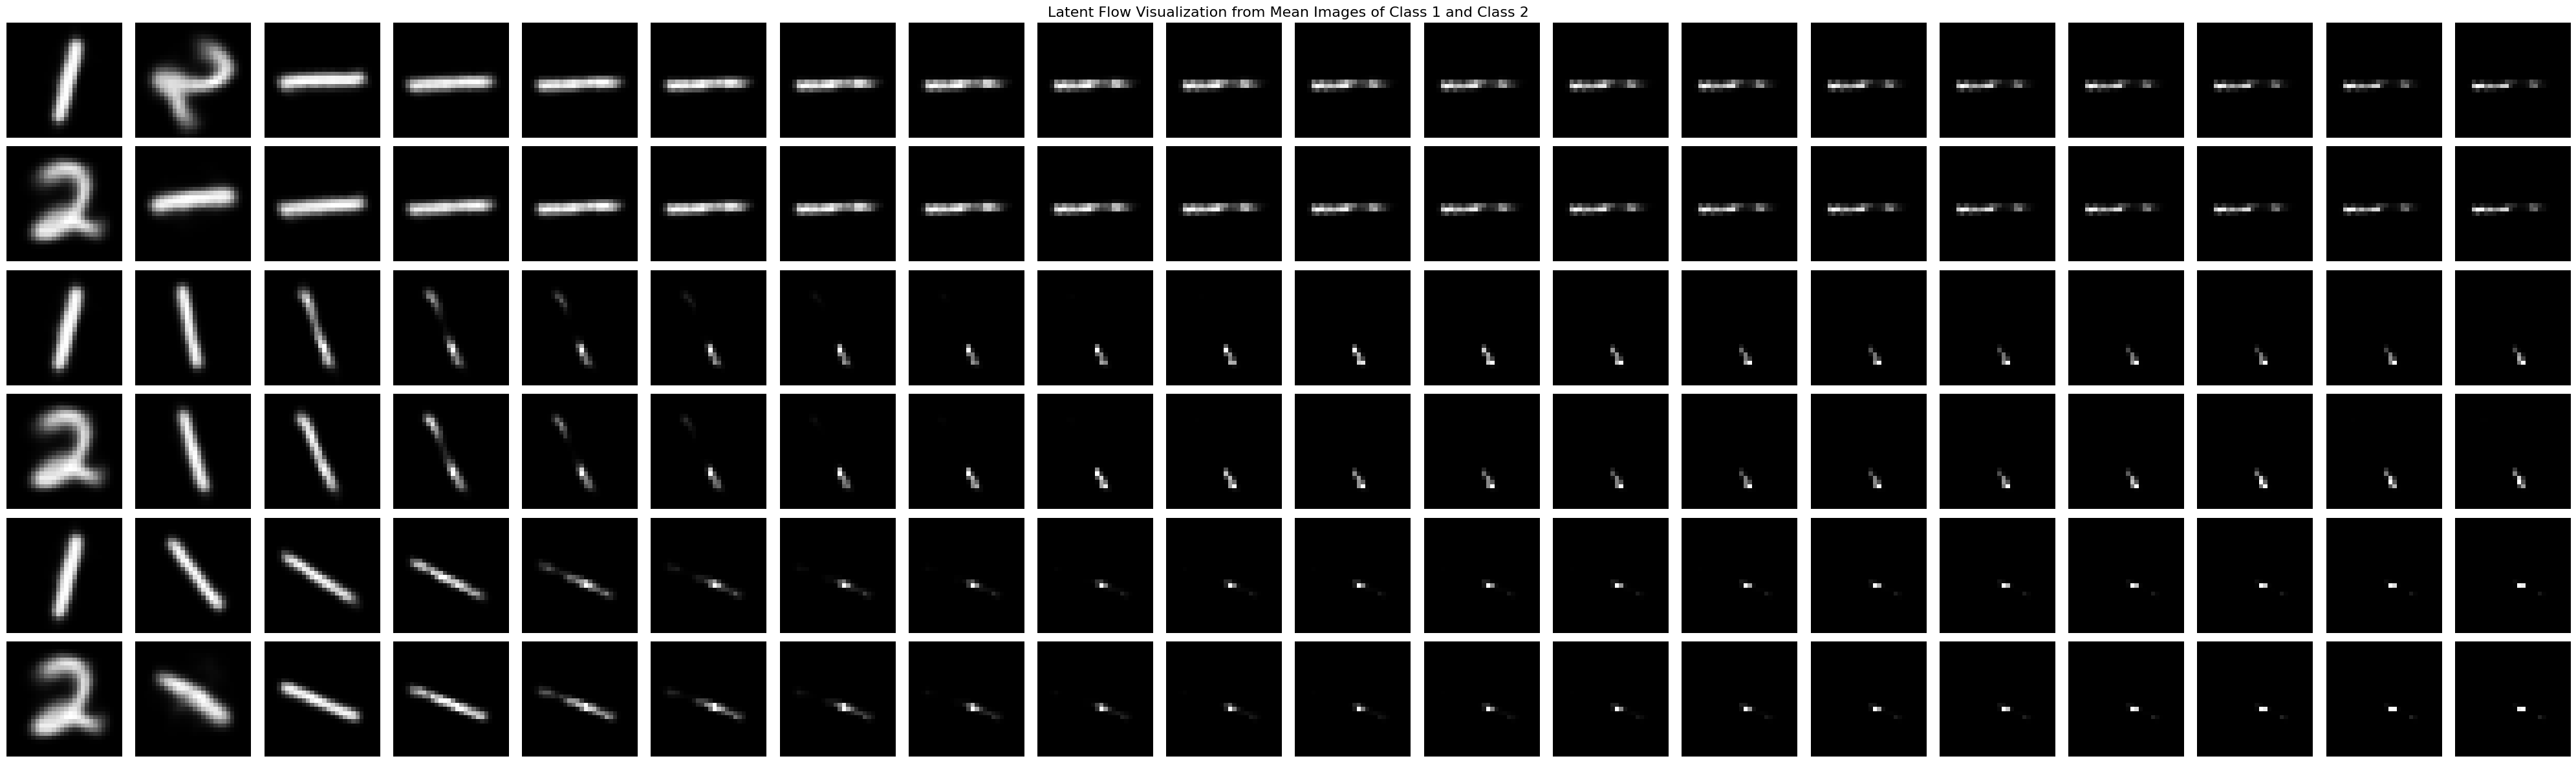

In [18]:
model.eval() 

sum_img_1 = None
sum_img_2 = None
count_1 = 0
count_2 = 0

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Computing mean images"):
        rotated_img, original_img, labels, angles = batch
        original_img = original_img.to(device).float() / 255.0
        
        if original_img.dim() == 3:
            original_img = original_img.unsqueeze(1)
        
        for i, lab in enumerate(labels):
            if lab.item() == 1:
                if sum_img_1 is None:
                    sum_img_1 = original_img[i]
                else:
                    sum_img_1 += original_img[i]
                count_1 += 1
            elif lab.item() == 2:
                if sum_img_2 is None:
                    sum_img_2 = original_img[i]
                else:
                    sum_img_2 += original_img[i]
                count_2 += 1

mean_img_1 = sum_img_1 / count_1  
mean_img_2 = sum_img_2 / count_2

print("Computed mean images for class 1 and class 2.")

mean_img_1 = mean_img_1.unsqueeze(0) if mean_img_1.dim() == 3 else mean_img_1
mean_img_2 = mean_img_2.unsqueeze(0) if mean_img_2.dim() == 3 else mean_img_2

with torch.no_grad():
    _, z_mean1, _ = model(mean_img_1)  
    _, z_mean2, _ = model(mean_img_2)  

num_steps_flow = 20  

flows_class1 = [] 
flows_class2 = []

# For class 1:
for idx, sym_net in enumerate(sym_nets):
    with torch.no_grad():
        z_current = z_mean1.clone()
        flow_images = []
        for step in range(num_steps_flow):
            h_z = model.fc_decode(z_current)
            img_decoded = model.decoder(h_z)
            flow_images.append(img_decoded.cpu().squeeze().numpy())
            delta_z = sym_net(z_current)
            z_current = z_current + epsilon * delta_z
        flows_class1.append(flow_images)

for idx, sym_net in enumerate(sym_nets):
    with torch.no_grad():
        z_current = z_mean2.clone()  
        flow_images = []
        for step in range(num_steps_flow):
            h_z = model.fc_decode(z_current)
            img_decoded = model.decoder(h_z)
            flow_images.append(img_decoded.cpu().squeeze().numpy())
            delta_z = sym_net(z_current)
            z_current = z_current + epsilon * delta_z
        flows_class2.append(flow_images)
        
num_gens = len(sym_nets)
fig, axes = plt.subplots(2 * num_gens, num_steps_flow, figsize=(num_steps_flow * 2, 2 * num_gens * 2))
for i in range(num_gens):
    for j in range(num_steps_flow):
        ax1 = axes[2*i, j] if num_gens > 1 else axes[j]
        ax1.imshow(flows_class1[i][j], cmap='gray')
        ax1.axis('off')
        if j == 0:
            ax1.set_ylabel(f"Gen {i+1} (Class 1)", fontsize=10)
        ax2 = axes[2*i+1, j] if num_gens > 1 else axes[j]
        ax2.imshow(flows_class2[i][j], cmap='gray')
        ax2.axis('off')
        if j == 0:
            ax2.set_ylabel(f"Gen {i+1} (Class 2)", fontsize=10)
plt.suptitle("Latent Flow Visualization from Mean Images of Class 1 and Class 2", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
for i,net in enumerate(sym_nets):
    torch.save({'model_state_dict':net.state_dict()},f'rotation_g_model{i}.pth')